# Skincare Analysis: Natural vs. Conventional Products

## Objective
This analysis investigates whether products marketed as "clean" or "natural" contain fewer potentially irritating ingredients compared to conventional skincare products.

We approximate skin tolerance using a simple irritation score based on the presence of known irritant ingredients.

In [1]:
import pandas as pd

## Data Loading

We load two datasets:
- Clean / natural skincare products
- Conventional skincare products

Additionally, we load a curated list of potentially irritating ingredients.

In [2]:
# Load datasets
df_clean = pd.read_csv("../data/clean_skincare_final.csv")
df_conv = pd.read_csv("../data/conventional_skincare_final.csv")
df_irritants = pd.read_csv("../data/irritants.csv")

## Initial Data Inspection

In [3]:
df_clean.shape

(232, 5)

In [4]:
df_conv.shape

(150, 4)

In [5]:
df_clean.head()

,product_name,product_brand,ingredients,clean_product,product_category
0,Embryolisse Lait-Crème Concentré Multi-Purpose...,Embryolisse,"Aqua, Paraffinum Liquidum, Stearic Acid, Glyce...",True,Moisturizer
1,Caudalie Vinoperfect Brightening Dark Spot Serum,Caudalie,"Aqua/Water/Eau, Butylene Glycol, Glycerin, Coc...",True,"Serum, Treatment/Active"
2,Caudalie Vinoperfect Brightening Dark Spot Ser...,Caudalie,"Aqua/Water/Eau, Butylene Glycol, Glycerin, Coc...",True,"Serum, Treatment/Active"
3,BEAUTYPRO Retinol Under Eye Patch,BEAUTYPRO,"Aqua,Glycerin,Sorbitol,Cellulose Gum,Kaolin,Po...",True,Treatment/Active
4,"Garnier Brightening 4% Vitamin C, Niacinamide,...",Garnier,"Aqua / Water, Glycerin, Dimethicone, Prunus Ar...",True,"Moisturizer, Treatment/Active"


In [6]:
df_conv.head()

,Product Brand,Product Name,Ingredients,Clean Product
0,LA MER,LA MER Crème de la Mer,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",False
1,LA MER,LA MER The Moisturizing Soft Cream,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",False
2,KIEHL'S SINCE 1851,KIEHL'S SINCE 1851 Ultra Facial Cream,"Water, Glycerin, Cyclohexasiloxane, Squalane, ...",False
3,LA MER,LA MER Little Miss Miracle Limited-Edition Crè...,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",False
4,KIEHL'S SINCE 1851,KIEHL'S SINCE 1851 Midnight Recovery Concentrate,Caprylic/Capric Triglyceride Dicaprylyl Carbon...,False


In [7]:
df_irritants.head()

,ingredient,category
0,alcohol denat,alcohol
1,ethanol,alcohol
2,isopropyl alcohol,alcohol
3,sd alcohol,alcohol
4,denatured alcohol,alcohol


## Column Standardization

Before merging both datasets, we standardize column names and column order to ensure a consistent structure.

In [8]:
# Check current column names
df_clean.columns

Index(['product_name', 'product_brand', 'ingredients', 'clean_product',
       'product_category'],
      dtype='object')

In [9]:
df_conv.columns

Index(['Product Brand', 'Product Name', 'Ingredients', 'Clean Product'], dtype='object')

In [10]:
# Rename clean dataset columns to match the conventional dataset
df_clean = df_clean.rename(columns={
    "product_name": "Product Name",
    "product_brand": "Product Brand",
    "ingredients": "Ingredients",
    "clean_product": "Clean Product"
})

In [11]:
# Keep only the columns needed for the comparison
df_clean = df_clean[["Product Brand", "Product Name", "Ingredients", "Clean Product"]]

In [12]:
# Check whether both datasets now have the same structure
df_clean.columns

Index(['Product Brand', 'Product Name', 'Ingredients', 'Clean Product'], dtype='object')

In [13]:
df_conv.columns

Index(['Product Brand', 'Product Name', 'Ingredients', 'Clean Product'], dtype='object')

In [14]:
df_clean.head()

,Product Brand,Product Name,Ingredients,Clean Product
0,Embryolisse,Embryolisse Lait-Crème Concentré Multi-Purpose...,"Aqua, Paraffinum Liquidum, Stearic Acid, Glyce...",True
1,Caudalie,Caudalie Vinoperfect Brightening Dark Spot Serum,"Aqua/Water/Eau, Butylene Glycol, Glycerin, Coc...",True
2,Caudalie,Caudalie Vinoperfect Brightening Dark Spot Ser...,"Aqua/Water/Eau, Butylene Glycol, Glycerin, Coc...",True
3,BEAUTYPRO,BEAUTYPRO Retinol Under Eye Patch,"Aqua,Glycerin,Sorbitol,Cellulose Gum,Kaolin,Po...",True
4,Garnier,"Garnier Brightening 4% Vitamin C, Niacinamide,...","Aqua / Water, Glycerin, Dimethicone, Prunus Ar...",True


In [15]:
df_conv.head()

,Product Brand,Product Name,Ingredients,Clean Product
0,LA MER,LA MER Crème de la Mer,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",False
1,LA MER,LA MER The Moisturizing Soft Cream,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",False
2,KIEHL'S SINCE 1851,KIEHL'S SINCE 1851 Ultra Facial Cream,"Water, Glycerin, Cyclohexasiloxane, Squalane, ...",False
3,LA MER,LA MER Little Miss Miracle Limited-Edition Crè...,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",False
4,KIEHL'S SINCE 1851,KIEHL'S SINCE 1851 Midnight Recovery Concentrate,Caprylic/Capric Triglyceride Dicaprylyl Carbon...,False


## Merge Datasets

We combine the clean and conventional skincare datasets into a single dataset for further analysis.

In [16]:
# Combine both datasets
df = pd.concat([df_clean, df_conv], ignore_index=True)

# Check shape
df.shape

(382, 4)

In [17]:
df["Clean Product"].value_counts()

Clean Product
True     232
False    150
Name: count, dtype: int64

In [18]:
#Convert the text in the columns in title format
text_cols = ["Product Brand", 'Product Name', 'Ingredients']
for col in text_cols:
    df[col] = df[col].str.strip().str.title()

#Drop invidual rows
df = df.drop([241, 245, 254, 258, 265, 272, 281, 286, 304, 300, 308, 314, 322, 326, 338, 340, 342, 343, 345, 349, 350, 352, 353, 354, 380])

df

,Product Brand,Product Name,Ingredients,Clean Product
0,Embryolisse,Embryolisse Lait-Crème Concentré Multi-Purpose...,"Aqua, Paraffinum Liquidum, Stearic Acid, Glyce...",True
1,Caudalie,Caudalie Vinoperfect Brightening Dark Spot Serum,"Aqua/Water/Eau, Butylene Glycol, Glycerin, Coc...",True
2,Caudalie,Caudalie Vinoperfect Brightening Dark Spot Ser...,"Aqua/Water/Eau, Butylene Glycol, Glycerin, Coc...",True
3,Beautypro,Beautypro Retinol Under Eye Patch,"Aqua,Glycerin,Sorbitol,Cellulose Gum,Kaolin,Po...",True
4,Garnier,"Garnier Brightening 4% Vitamin C, Niacinamide,...","Aqua / Water, Glycerin, Dimethicone, Prunus Ar...",True
...,...,...,...,...
376,Peter Thomas Roth,Peter Thomas Roth Water Drench Hyaluronic Clou...,"Water, Saccharide Isomerate, Sodium Hyaluronat...",False
377,Estée Lauder,Estée Lauder Idealist Pore Minimizing Skin Ref...,Idealist Extra Pore Min Skin Refin Division: E...,False
378,Estée Lauder,Estée Lauder Enlighten Dark Spot Correcting Ni...,Enlighten Dark Spot Corr Night Srm Division: E...,False
379,Dr. Jart+,Dr. Jart+ Dermaclear™ Micro Milk Peel,"Water, Hydrogenated Polydecene, Caprylic/Capri...",False


## Irritation Score

We calculate an irritation score for each product based on the number of potentially irritating ingredients present in the ingredient list.

In [19]:
# Lowercase for matching
df["Ingredients"] = df["Ingredients"].str.lower()
df_irritants["ingredient"] = df_irritants["ingredient"].str.lower()

In [20]:
# Function to count irritants in a product
def count_irritants(ingredients, irritant_list):
    count = 0
    for irritant in irritant_list:
        if irritant in ingredients:
            count += 1
    return count

In [21]:
# Create irritation score
irritant_list = df_irritants["ingredient"].tolist()

df["irritation_score"] = df["Ingredients"].apply(
    lambda x: count_irritants(x, irritant_list)
)

In [22]:
df[["Product Name", "irritation_score"]].head()

,Product Name,irritation_score
0,Embryolisse Lait-Crème Concentré Multi-Purpose...,2
1,Caudalie Vinoperfect Brightening Dark Spot Serum,2
2,Caudalie Vinoperfect Brightening Dark Spot Ser...,2
3,Beautypro Retinol Under Eye Patch,5
4,"Garnier Brightening 4% Vitamin C, Niacinamide,...",2


In [23]:
combined = df

In [24]:
df["irritation_score"].describe()
#df["irritation_score"].value_counts()

count    357.000000
mean       3.128852
std        2.791476
min        0.000000
25%        2.000000
50%        2.000000
75%        5.000000
max       13.000000
Name: irritation_score, dtype: float64

In [25]:
#Stats of irritation scores by product
df.groupby('Clean Product')['irritation_score'].agg(['mean', 'median', 'std', 'count']).round(2)


,mean,median,std,count
Clean Product,,,,
False,4.34,3.0,3.21,125
True,2.48,2.0,2.30,232


In [26]:
# For each irritant, what % of clean/regular products contain it?
results = {}

for irritant in df_irritants['ingredient'].str.lower():
    contains = df['Ingredients'].str.lower().str.contains(irritant, regex=False, na=False)
    clean_total = (df['Clean Product']==True).sum()
    regular_total = (df['Clean Product']==False).sum()

    clean_with = contains[df['Clean Product']==True].sum()
    regular_with = contains[df['Clean Product']==False].sum()

    results[irritant] = {
        'Clean %': round((clean_with/clean_total)*100, 1),
        'Conventional %': round((regular_with/regular_total)*100, 1)
    }

irritant_presence = pd.DataFrame(results).T

irritant_presence

,Clean %,Conventional %
alcohol denat,6.9,16.8
ethanol,27.2,82.4
isopropyl alcohol,0.4,0.8
sd alcohol,0.0,4.0
denatured alcohol,0.0,0.0
benzyl alcohol,11.2,6.4
parfum,35.8,5.6
fragrance,33.6,48.8
perfume,0.0,0.0
aroma,0.0,1.6


## Results: Irritation Score Comparison

The average irritation score is higher for conventional products (3.37) than for clean products (2.75).

This suggests that clean skincare products tend to contain fewer potentially irritating ingredients compared to conventional products.

## Visualization: Irritation Score Distribution

We visualize the distribution of irritation scores for clean and conventional products to better understand differences between the groups.

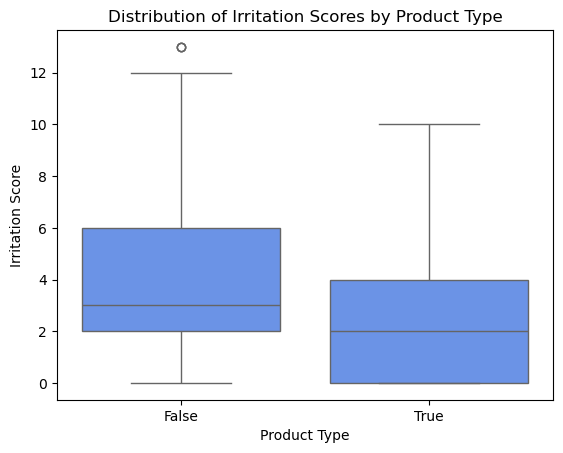

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create boxplot
sns.boxplot(x="Clean Product", y="irritation_score", data=df)

# Labels
plt.xlabel("Product Type")
plt.ylabel("Irritation Score")
plt.title("Distribution of Irritation Scores by Product Type")

plt.show()

### Initial Visualization

This plot shows the distribution of irritation scores grouped by product type. While it already indicates differences between the groups, the labeling is not yet intuitive for interpretation.

<Axes: xlabel='Clean Product Label', ylabel='irritation_score'>

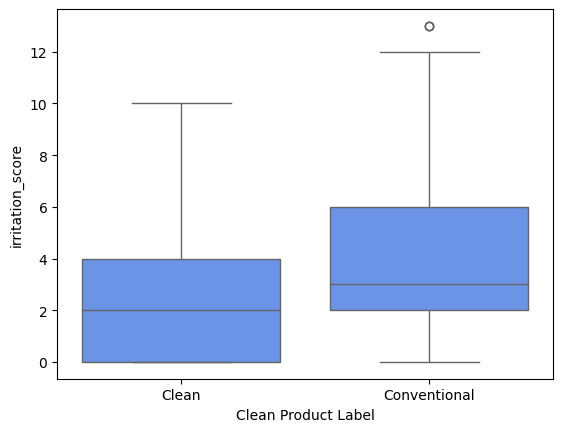

In [28]:

df["Clean Product Label"] = df["Clean Product"].map({
    True: "Clean",
    False: "Conventional"
})

sns.boxplot(x="Clean Product Label", y="irritation_score", data=df)

### Improved Visualization

After relabeling the product types, the plot becomes more interpretable. We observe that conventional products tend to have higher irritation scores and more extreme values compared to clean products.

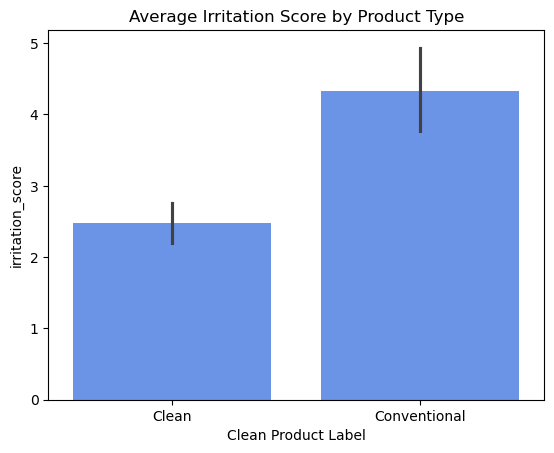

In [29]:
sns.barplot(x="Clean Product Label", y="irritation_score", data=df)
plt.title("Average Irritation Score by Product Type")
plt.show()

### Average Irritation Score Comparison

This bar plot shows the average irritation score for clean and conventional products. Conventional products have a higher mean irritation score, indicating that they tend to contain more potentially irritating ingredients on average.

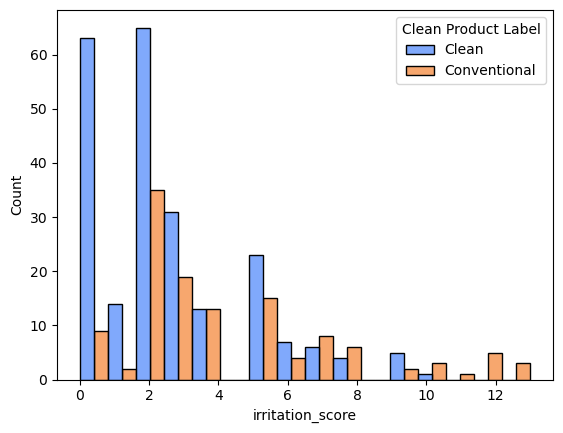

In [30]:
sns.histplot(data=df, x="irritation_score", hue="Clean Product Label", multiple="dodge")#bins=15 )
plt.show()

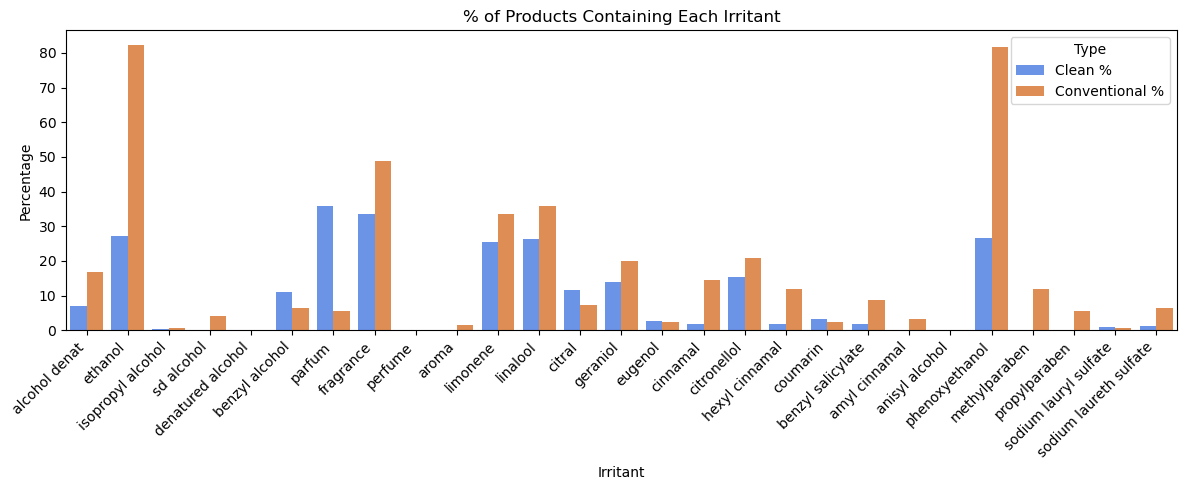

In [31]:
plot_data = irritant_presence.reset_index().melt(
    id_vars='index',
    var_name='Type',
    value_name='Percentage'
)
plot_data.columns = ['Irritant', 'Type', 'Percentage']

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_data, x='Irritant', y='Percentage', hue='Type')
plt.title('% of Products Containing Each Irritant')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Distribution of Irritation Scores

This histogram shows how irritation scores are distributed across clean and conventional products. Clean products are more concentrated in the lower score range, while conventional products show a wider distribution with more high-score occurrences. This suggests that higher irritation levels are more common among conventional products.

### Conclusion

Our analysis shows that conventional skincare products tend to have higher irritation scores compared to clean products, with a higher average and a broader distribution overall. While this suggests that clean products may be less likely to contain ingredients associated with skin irritation, they are by no means irritant-free. This is an important distinction for anyone with sensitive skin or a history of allergies, to always check the ingredient list regardless of how a product is marketed.


Among conventional products, the most prevalent irritant is ethanol, a type of alcohol. In clean beauty, the most common irritant is parfum/fragrance, present in nearly 40% of our sample. Fragrance is one of the leading causes of contact allergy in cosmetics, so consumers should keep this in mind when purchasing skincare marketed as clean.

### Limitations

This analysis is based on a predefined list of potentially irritating ingredients and does not account for concentration, formulation context, or individual skin sensitivity, all of which play a significant role in how a product actually affects the skin.

Our sample size is relatively small, which limits the generalizability of these findings.

We did not address differences in product formulations across regions; the same product can vary significantly between markets like the US and EU due to differing regulatory standards, which may affect both ingredient selection and irritation potential.

In [32]:
df.to_csv('products_with_scores.csv', index=False)